In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

/home/petedowney/miniconda3/envs/MLQuanta/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)
/tmp/ipykernel_2337/3635821465.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case whe

Average MSE: 1.5822759
First 10 predictions: [2.819586 2.819586 2.819586 2.819586 2.819586 2.819586 2.819586 2.819586
 2.819586 2.819586]
First 10 actuals: [2. 2. 2. 2. 2. 2. 6. 7. 2. 3.]
First 10 residuals: [ 0.81958604  0.81958604  0.81958604  0.81958604  0.81958604  0.81958604
 -3.180414   -4.180414    0.81958604 -0.18041396]
Residuals mean: -0.021691894 Residuals std: 1.2576984


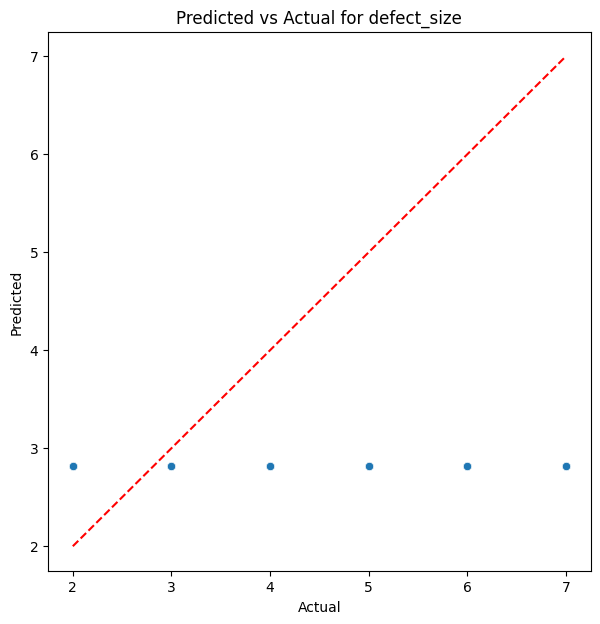

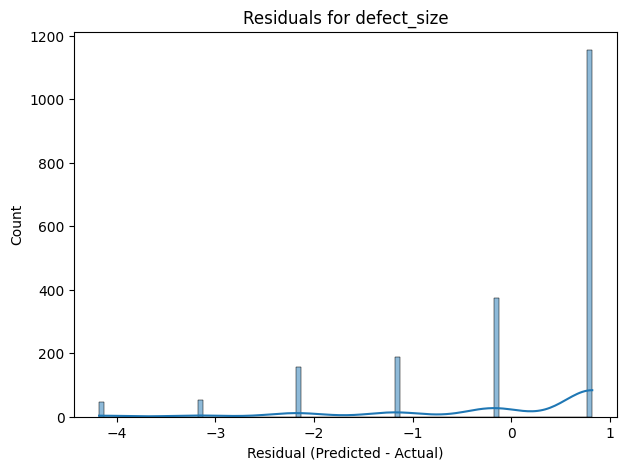

In [8]:
import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data

import importlib
importlib.reload(GCN)

# Load model (update label as needed)
OUTPUT_LABEL = 'defect_size'

TYPE = 'val'

# Load validation data
X_val = np.load('filtered_data/{}_X_{}.npy'.format(OUTPUT_LABEL, TYPE))
adj_val = np.load('filtered_data/{}_adj_{}.npy'.format(OUTPUT_LABEL, TYPE))
y_val = np.load('filtered_data/{}_y_{}.npy'.format(OUTPUT_LABEL, TYPE))


# For X_val
X_val = np.array(X_val)
#X_val = np.append(X_val, np.ones((X_val.shape[0], X_val.shape[1], 1)), axis=2)
X_val = X_val[:, :, 0][:, :, np.newaxis]  # Keep only the atomic number feature
for n in range(len(X_val)):
    for node in range(len(X_val[n])):
        X_val[n, node, 0] = y_val[n]
X_val = X_val.tolist()

# Convert to tensors
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
X_val_tensor = torch.tensor(X_val, dtype=torch.float).to(device)
adj_val_tensor = torch.tensor(adj_val, dtype=torch.float).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float).to(device)

model = GCN.GraphConv(1, 0.001).to(device)
model.load_state_dict(torch.load(f'./models/model_{OUTPUT_LABEL}.pt', map_location=device))
model.eval()


# Prepare validation dataset for prediction
val_graphs = []
for i in range(len(X_val_tensor)):
    edge_index, _ = dense_to_sparse(adj_val_tensor[i])
    data = Data(x=X_val_tensor[i], edge_index=edge_index)
    val_graphs.append(data)

# Predict on validation set
preds = []
with torch.no_grad():
    for data in val_graphs:
        x = data.x
        edge_index = data.edge_index
        batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
        pred = model(x, data.edge_index, data.edge_weight, batch)
        preds.append(pred.cpu().numpy().flatten()[0])
        #preds.append(0.5)
#Average MSE: 0.07577329541259877
#Average MSE: 0.07528475
preds = np.array(preds)
y_true = y_val_tensor.cpu().numpy().flatten()

MSE = np.mean((preds - y_true) ** 2)
print('Average MSE:', MSE)

# Diagnostic prints
residuals = preds - y_true
print('First 10 predictions:', preds[:10])
print('First 10 actuals:', y_true[:10])
print('First 10 residuals:', residuals[:10])
print('Residuals mean:', residuals.mean(), 'Residuals std:', residuals.std())

# Plot predicted vs actual
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_true, y=preds)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Predicted vs Actual for {OUTPUT_LABEL}')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.show()

# Plot residuals
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=100, kde=True)
plt.xlabel('Residual (Predicted - Actual)')
plt.title(f'Residuals for {OUTPUT_LABEL}')
plt.show()